In [ ]:
# Import libraries
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import modules
from model import config
from model.data_loader_frag import load_fragments, fragments_to_dataframe
from model.problem import AssemblyProblem
from algorithms.random_search import optimize

In [2]:
# Import fragments and optimization problem
fragments = load_fragments()
problem = AssemblyProblem(fragments)

fragments_df = fragments_to_dataframe(fragments)

print(f"Loaded fragments: {len(fragments)}")
print(f"Dense mode: {problem.use_dense}")
print(f"Min overlap: {problem.min_overlap}")
print(f"Break factor: {problem.break_factor}")

fragments_df.head()

Loaded fragments: 69
Dense mode: True
Min overlap: 20
Break factor: 2


,fragment_id,source,copy,frag_start,frag_end,frag_len,sequence
0,simulated_chromosome_frag_1,simulated_chromosome,1,4624,4893,269,CCAGAGAAGCCGGACCAAGACAGTAAGCGAGGAATCTAGCCCGACT...
1,simulated_chromosome_frag_2,simulated_chromosome,2,4481,4885,404,ATGCGGGCGCGGCGAGATATACAGTGGGCCGATACTATAGTCCGTC...
2,simulated_chromosome_frag_3,simulated_chromosome,3,2553,2940,387,AACGACTATGATAGAGCGGACGTAAGGCTCACAGGGTGTGCGGGCA...
3,simulated_chromosome_frag_4,simulated_chromosome,3,134,510,376,AACGAAAGATTAAGAATGCTTAACCCGGTACCTAACCCATCTGATT...
4,simulated_chromosome_frag_5,simulated_chromosome,4,489,797,308,CACTCTTAAAGTCGTGTTAAAAGGAGTAGTATTAACGTCGAGGATT...


## Random Search

In [ ]:
rng = random.Random(42) # or use config.py:   rng = random.Random(config.SEED)

result = optimize(
    problem=problem,
    config=config,
    rng=rng,
)

print("Run complete.")
print(f"Best score: {result['best_score']:.2f}")
print(f"Evaluations: {result['evaluations']}")
print(f"Runtime: {result['runtime_sec']:.3f} sec")
print(f"Breaks: {result['breaks']}")
print(f"Contigs: {result['contigs']}")
print(f"Total overlap: {result['total_overlap']}")

Run complete.
Best score: 35425.00
Evaluations: 10000
Runtime: 0.195 sec
Breaks: 55
Contigs: 56
Total overlap: 2148


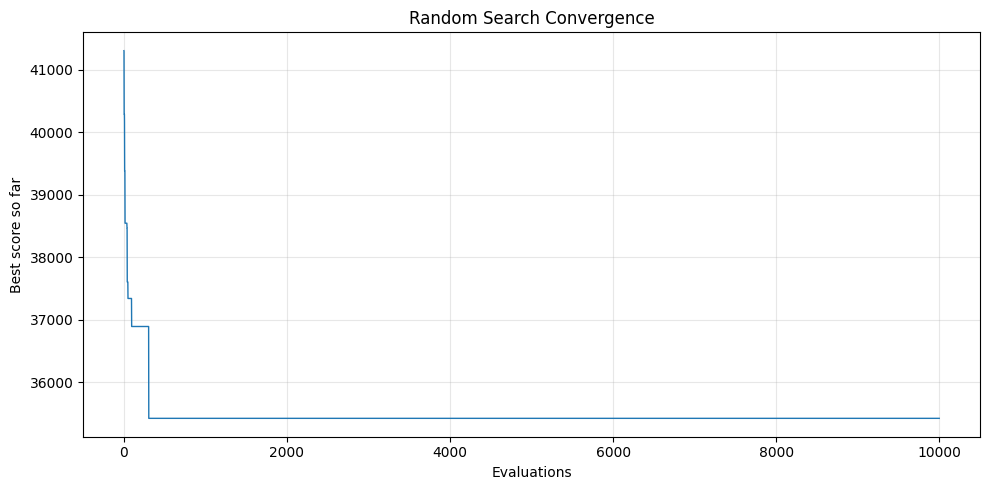

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(result["history"], linewidth=1)
plt.xlabel("Evaluations")
plt.ylabel("Best score so far")
plt.title("Random Search Convergence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
best_perm = result["best_solution"]

print("=" * 70)
print("BEST SOLUTION FOUND")
print("=" * 70)
print("\nPermutation order (fragment IDs):")
print(best_perm)
print(f"\nTotal cost: {result['best_score']:.2f}")

print("\n" + "=" * 70)
print("ALGORITHM STATISTICS")
print("=" * 70)
print(f"Total evaluations: {result['evaluations']}")
print(f"Runtime (sec): {result['runtime_sec']:.4f}")
print(f"Best cost: {result['best_score']:.2f}")
print(f"Breaks: {result['breaks']}")
print(f"Contigs: {result['contigs']}")
print(f"Total overlap: {result['total_overlap']}")

BEST SOLUTION FOUND

Permutation order (fragment IDs):
['simulated_chromosome_frag_42', 'simulated_chromosome_frag_37', 'simulated_chromosome_frag_28', 'simulated_chromosome_frag_4', 'simulated_chromosome_frag_50', 'simulated_chromosome_frag_36', 'simulated_chromosome_frag_38', 'simulated_chromosome_frag_16', 'simulated_chromosome_frag_46', 'simulated_chromosome_frag_60', 'simulated_chromosome_frag_32', 'simulated_chromosome_frag_67', 'simulated_chromosome_frag_51', 'simulated_chromosome_frag_62', 'simulated_chromosome_frag_39', 'simulated_chromosome_frag_34', 'simulated_chromosome_frag_14', 'simulated_chromosome_frag_8', 'simulated_chromosome_frag_9', 'simulated_chromosome_frag_40', 'simulated_chromosome_frag_27', 'simulated_chromosome_frag_18', 'simulated_chromosome_frag_68', 'simulated_chromosome_frag_20', 'simulated_chromosome_frag_66', 'simulated_chromosome_frag_13', 'simulated_chromosome_frag_30', 'simulated_chromosome_frag_47', 'simulated_chromosome_frag_33', 'simulated_chromoso

In [7]:
best_df = pd.DataFrame({"fragment_id": best_perm})
best_df = best_df.merge(
    fragments_df[["fragment_id", "source", "copy", "frag_start", "frag_end", "frag_len"]],
    on="fragment_id",
    how="left"
)

best_df.head(20)

,fragment_id,source,copy,frag_start,frag_end,frag_len
0,simulated_chromosome_frag_42,simulated_chromosome,50,3846,4236,390
1,simulated_chromosome_frag_37,simulated_chromosome,45,3396,3835,439
2,simulated_chromosome_frag_28,simulated_chromosome,33,961,1384,423
3,simulated_chromosome_frag_4,simulated_chromosome,3,134,510,376
4,simulated_chromosome_frag_50,simulated_chromosome,57,3933,4210,277
5,simulated_chromosome_frag_36,simulated_chromosome,43,4063,4317,254
6,simulated_chromosome_frag_38,simulated_chromosome,46,83,418,335
7,simulated_chromosome_frag_16,simulated_chromosome,17,0,258,258
8,simulated_chromosome_frag_46,simulated_chromosome,55,0,444,444
9,simulated_chromosome_frag_60,simulated_chromosome,65,285,554,269


In [ ]:
seeds = [1, 42, 123, 999]
results_grid = {}

print("Testing random seeds...\n")

for seed in seeds:
    key = f"seed={seed}"
    print(f"  {key}...", end=" ", flush=True)

    rng = random.Random(seed)
    res = optimize(
        problem=problem,
        config=config,
        rng=rng,
    )

    results_grid[key] = res
    print(f"best_score={res['best_score']:.1f}")

Testing random seeds...

  seed=1... best_score=35855.0
  seed=42... best_score=35425.0
  seed=123... best_score=35794.0
  seed=999... best_score=35556.0


In [14]:
summary_rows = []
for key, res in results_grid.items():
    summary_rows.append({
        "setting": key,
        "best_score": res["best_score"],
        "evaluations": res["evaluations"],
        "runtime_sec": res["runtime_sec"],
        "best_breaks": res["breaks"],
        "best_contigs": res["contigs"],
        "best_total_overlap": res["total_overlap"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("best_score")
summary_df

,setting,best_score,evaluations,runtime_sec,best_breaks,best_contigs,best_total_overlap
1,seed=42,35425,10000,0.187034,55,56,2148
3,seed=999,35556,10000,0.187430,57,58,1942
2,seed=123,35794,10000,0.187340,57,58,2596
0,seed=1,35855,10000,0.186722,57,58,1865


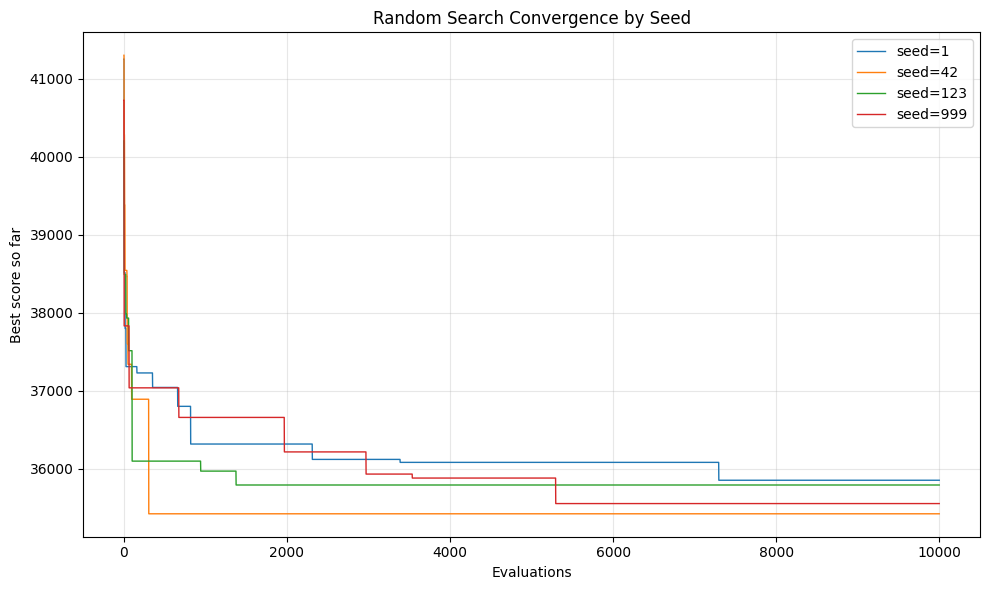

In [13]:
plt.figure(figsize=(10, 6))
for key, res in results_grid.items():
    plt.plot(res["history"], label=key, linewidth=1)

plt.title("Random Search Convergence by Seed")
plt.xlabel("Evaluations")
plt.ylabel("Best score so far")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()